# Учимся строить графики

In [20]:
import warnings 

import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns 

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-deep')

In [21]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/iad34/seminars/master/materials/data_sem1.csv",
    sep=";",
)

In [22]:
print(f'Data Size: {df.shape}')

Data Size: (891, 12)


In [23]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,Braund; Mr. Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,Cumings; Mrs. John Bradley (Florence Briggs Th...,female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,Heikkinen; Miss. Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,Futrelle; Mrs. Jacques Heath (Lily May Peel),female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,Allen; Mr. William Henry,male,35.0,0,0,373450,8.0500,NaN,S


По диагонали — маргинальное распределение каждой числовой переменной с учётом целевой переменной. В остальных ячейках — scatter plot каждой пары числовых переменных с учётом целевой переменной.

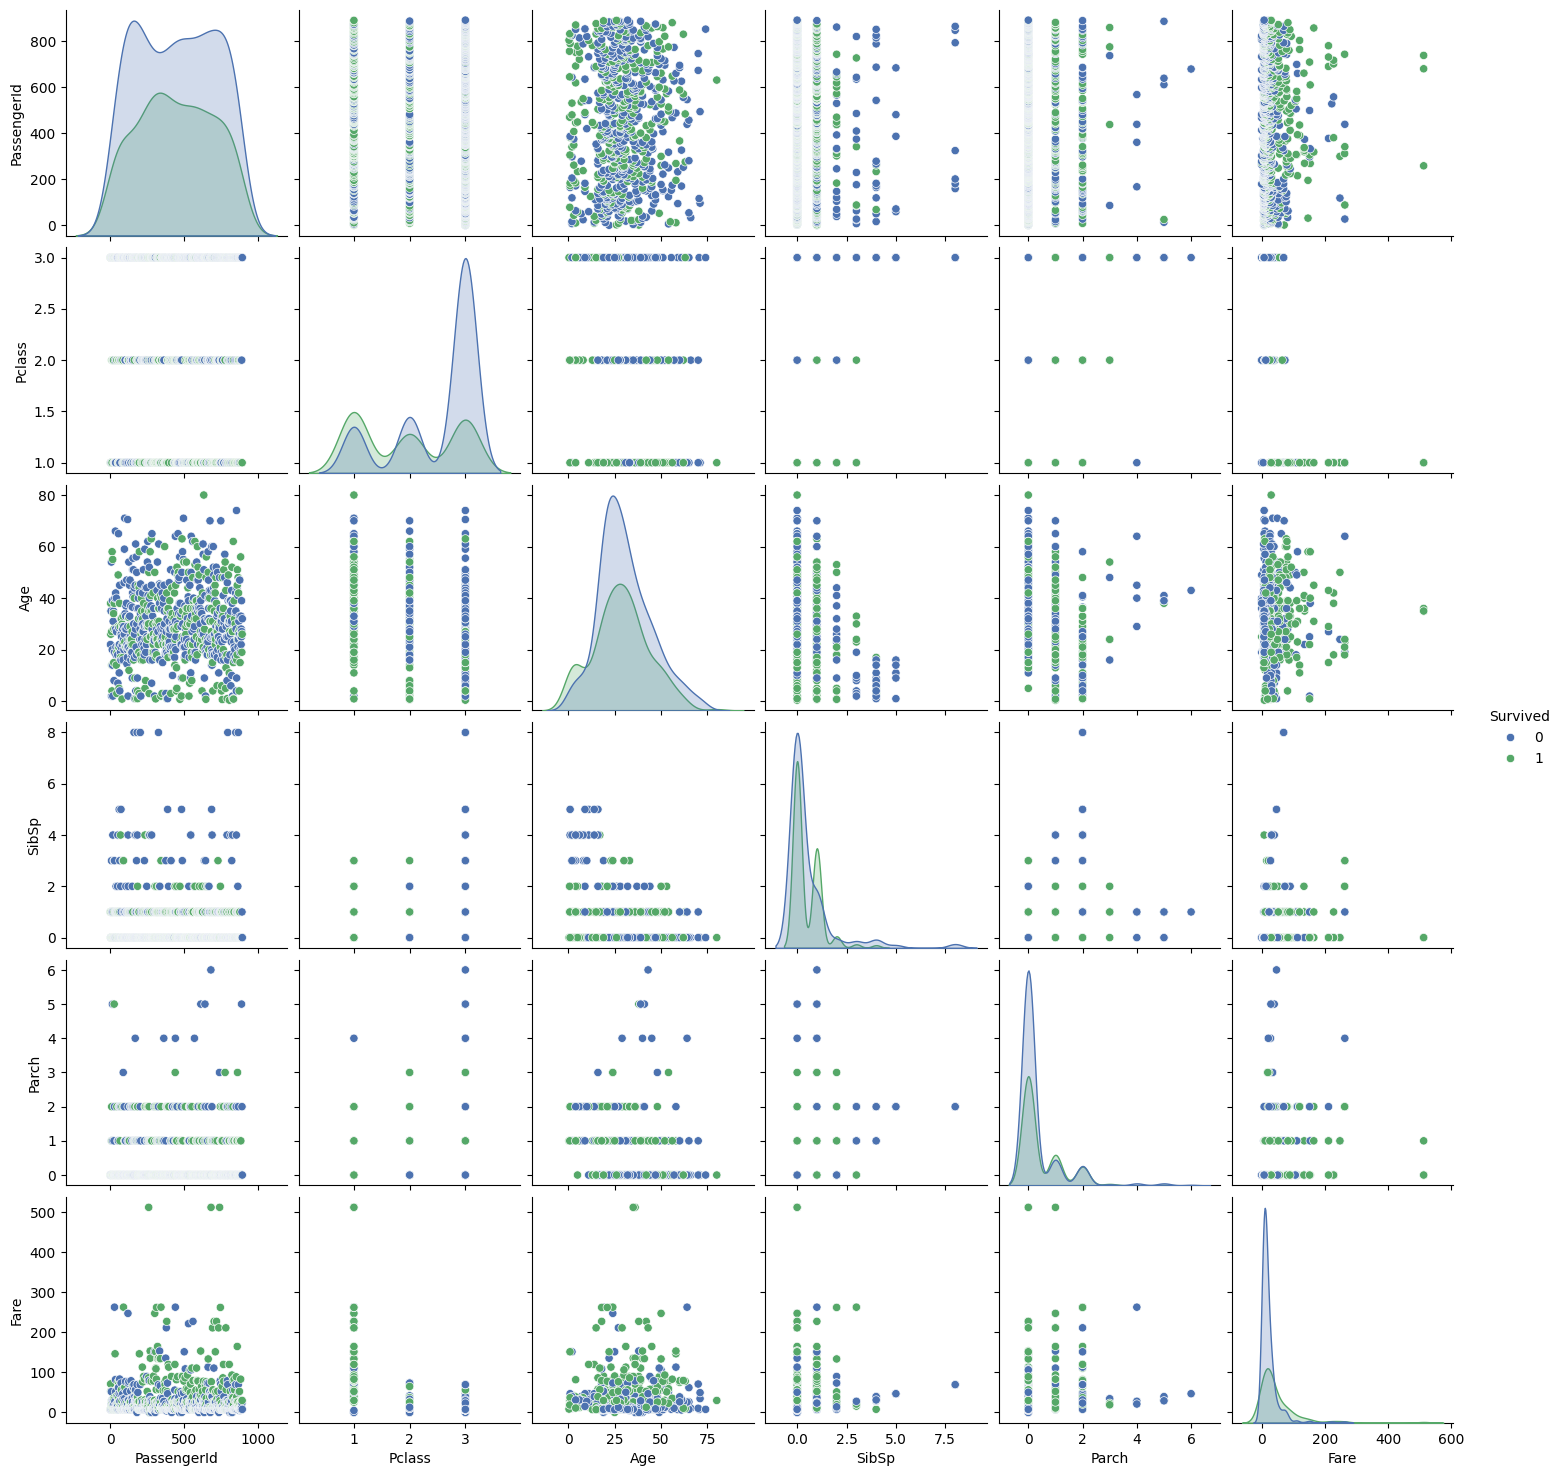

In [24]:
sns.pairplot(df, hue="Survived");

<Axes: title={'center': 'Survived'}>

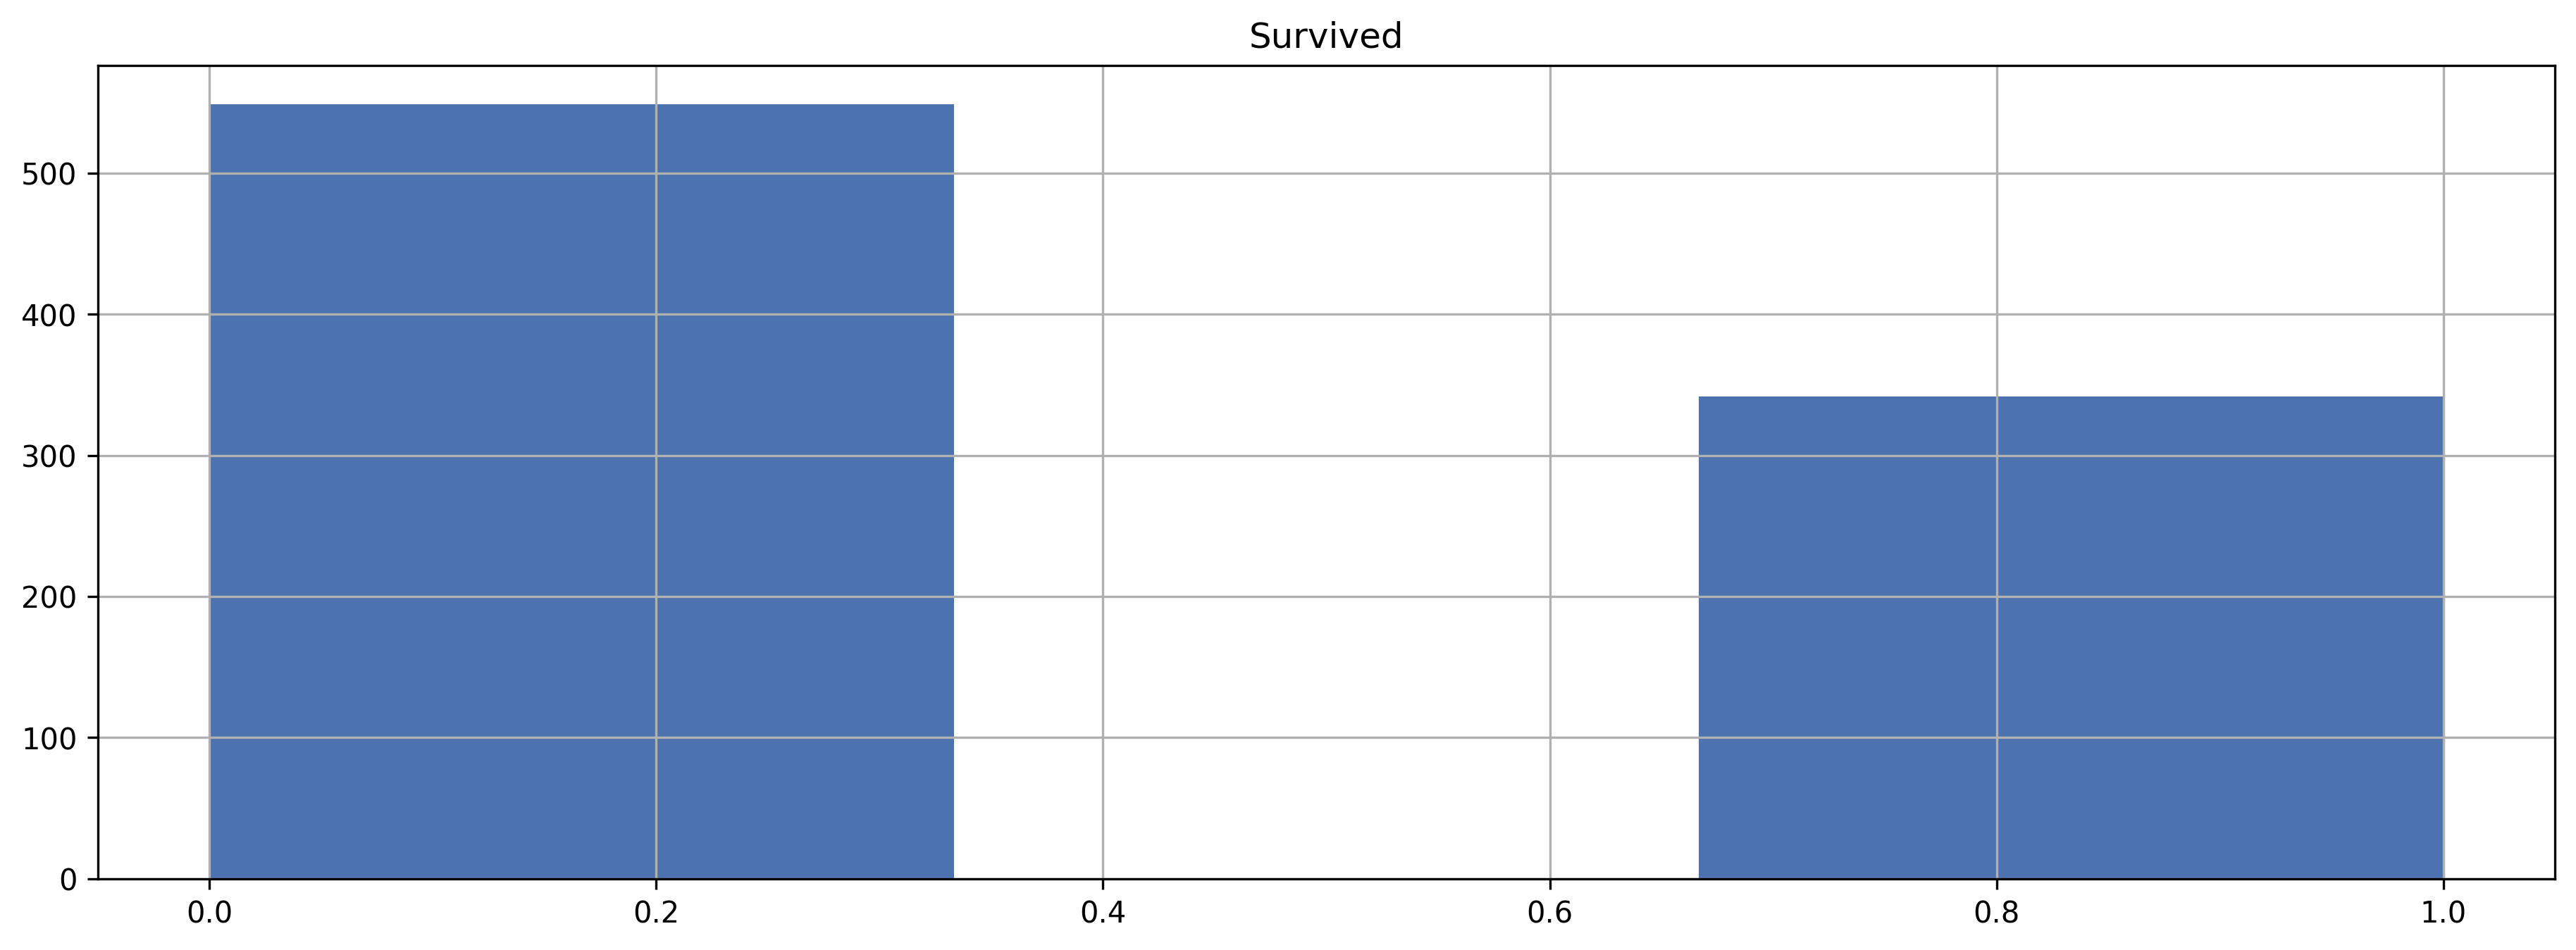

In [25]:
plt.figure(figsize=(15,5), dpi=300)
plt.title("Survived")
df['Survived'].hist(bins=3)

То же самое, но только с matplotlib

(array([549.,   0., 342.]),
 array([0.        , 0.33333333, 0.66666667, 1.        ]),
 <BarContainer object of 3 artists>)

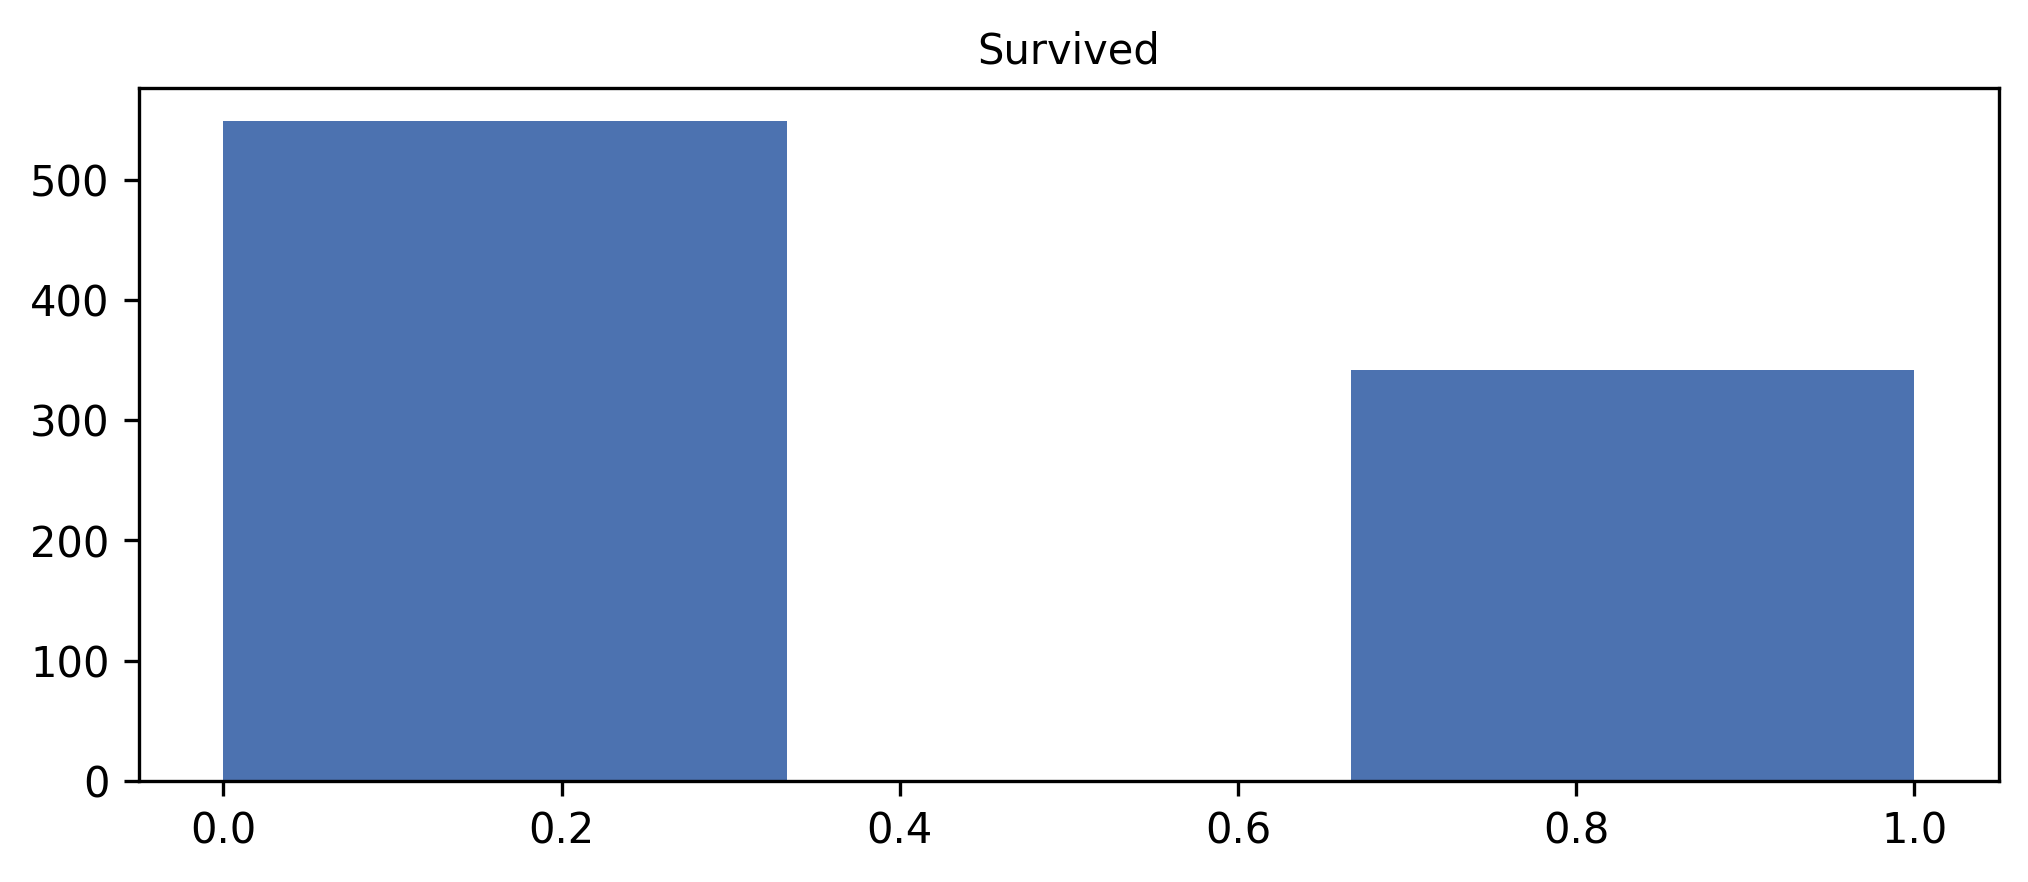

In [26]:
plt.figure(figsize=(8,3),dpi=300)
plt.title('Survived',fontsize=10)
plt.hist(df['Survived'],bins=3)

Построим гистаграмму по возрасту

<Axes: title={'center': 'Age'}>

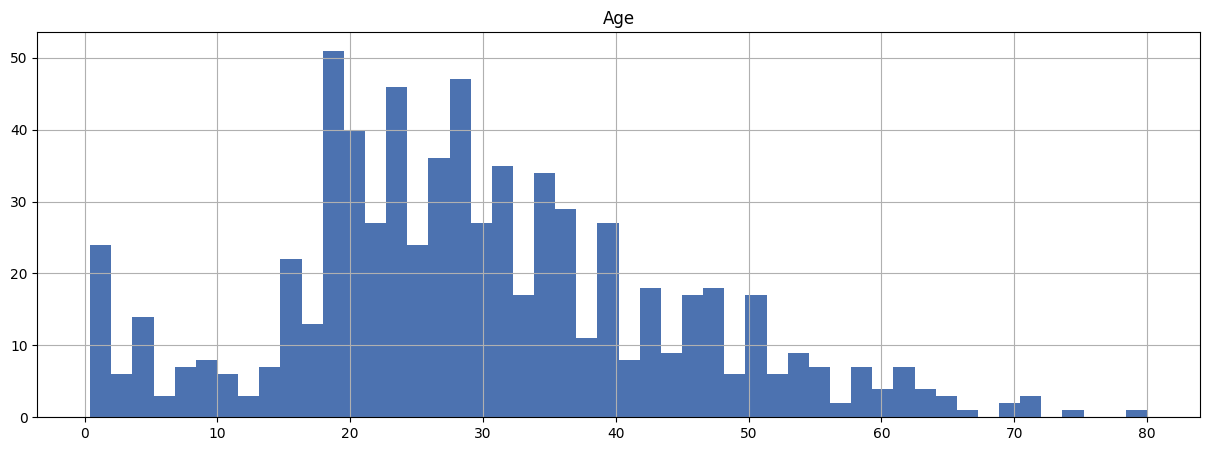

In [27]:
# plt.figure(figsize=(15,5),dpi=300)
plt.rcParams['figure.figsize'] = (15,5)
plt.title('Age')
df['Age'].hist(bins=50)

Для легкого разделения по группам выживших и не выживших используем seaborn

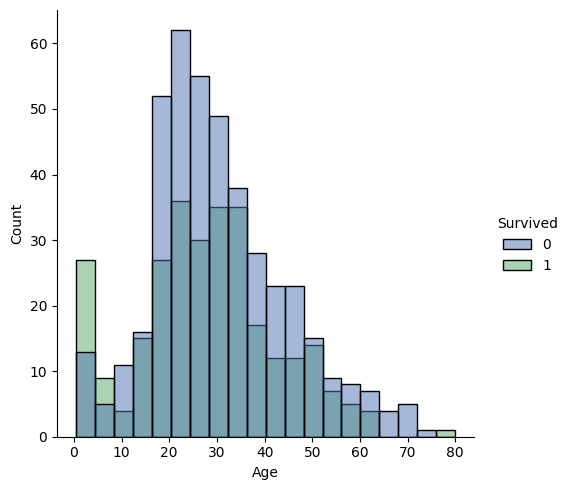

In [28]:
sns.displot(df,x="Age",hue='Survived')

(array([[15.,  5., 11.,  2.,  3.,  2.,  1.,  3.,  3., 10.,  6., 18.,  8.,
         11., 20.,  6., 17., 15., 10., 17.,  7., 17., 12.,  5., 11.,  2.,
          7.,  3.,  5.,  7.,  4.,  7.,  3.,  4.,  3.,  0.,  3.,  2.,  2.,
          2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.],
        [24.,  6., 14.,  3.,  7.,  8.,  6.,  3.,  7., 22., 13., 51., 40.,
         27., 46., 24., 36., 47., 27., 35., 17., 34., 29., 11., 27.,  8.,
         18.,  9., 17., 18.,  6., 17.,  6.,  9.,  7.,  2.,  7.,  4.,  7.,
          4.,  3.,  1.,  0.,  2.,  3.,  0.,  1.,  0.,  0.,  1.]]),
 array([ 0.42  ,  2.0116,  3.6032,  5.1948,  6.7864,  8.378 ,  9.9696,
        11.5612, 13.1528, 14.7444, 16.336 , 17.9276, 19.5192, 21.1108,
        22.7024, 24.294 , 25.8856, 27.4772, 29.0688, 30.6604, 32.252 ,
        33.8436, 35.4352, 37.0268, 38.6184, 40.21  , 41.8016, 43.3932,
        44.9848, 46.5764, 48.168 , 49.7596, 51.3512, 52.9428, 54.5344,
        56.126 , 57.7176, 59.3092, 60.9008, 62.4924, 64.084 , 65.6756

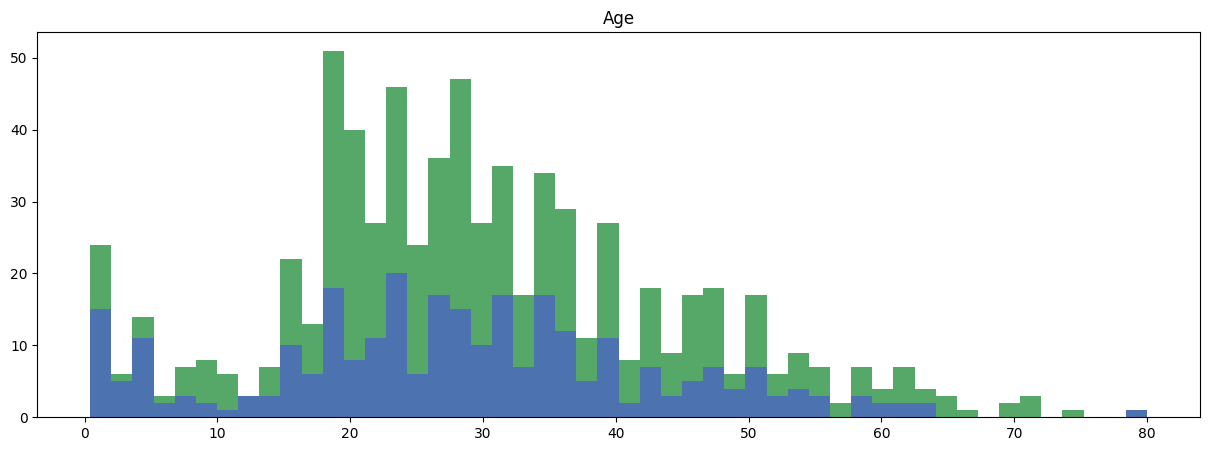

In [29]:
# в матплотлиб будет менее красиво
plt.title("Age")
plt.hist(
    [df["Age"][df['Survived']==1],df["Age"][df['Survived']==0]],
    stacked=True,
    bins=50
)

расчитаем корреляцию

In [35]:
df.drop('Name',axis=1,inplace=True)

In [53]:
df.drop('Ticket',axis=1,inplace=True)

In [55]:
df.drop('Cabin',axis=1,inplace=True)

In [39]:
df['Sex'] = df['Sex'].apply(lambda x: 1 if x == 'male' else 0)

In [57]:
df.drop('Embarked',axis=1,inplace=True)

In [59]:
df

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,1,22.0,1,0,7.2500
1,2,1,1,0,38.0,1,0,71.2833
2,3,1,3,0,26.0,0,0,7.9250
3,4,1,1,0,35.0,1,0,53.1000
4,5,0,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...,...,...
886,887,0,2,1,27.0,0,0,13.0000
887,888,1,1,0,19.0,0,0,30.0000
888,889,0,3,0,NaN,1,2,23.4500
889,890,1,1,1,26.0,0,0,30.0000


In [60]:
df.corr()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.054139,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.541455,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,0.128604,-0.369226,0.083081,0.018443,-0.549500
Sex,0.054139,-0.541455,0.128604,1.000000,0.097018,-0.113174,-0.262001,-0.180626
Age,0.036847,-0.077221,-0.369226,0.097018,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.113174,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.262001,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,-0.180626,0.096067,0.159651,0.216225,1.000000


<Axes: >

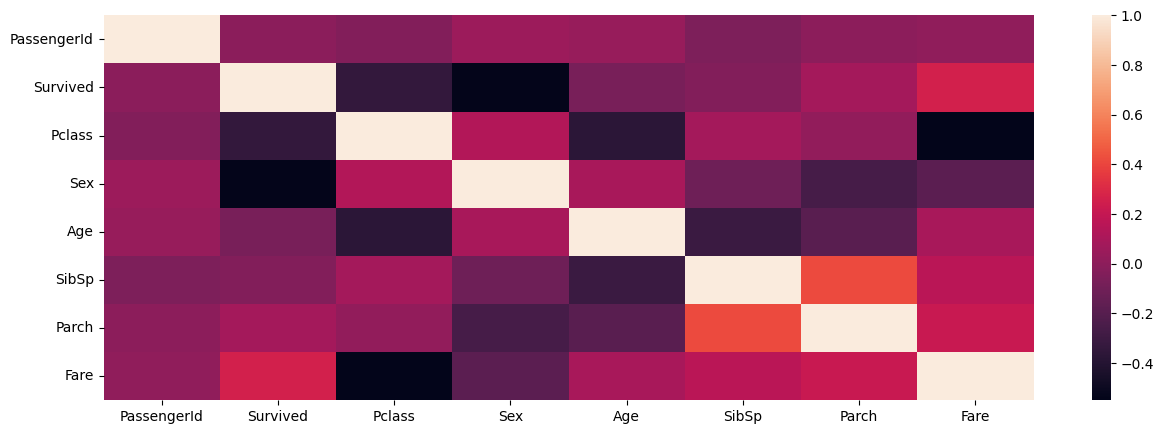

In [61]:
sns.heatmap(df.corr())

<Axes: >

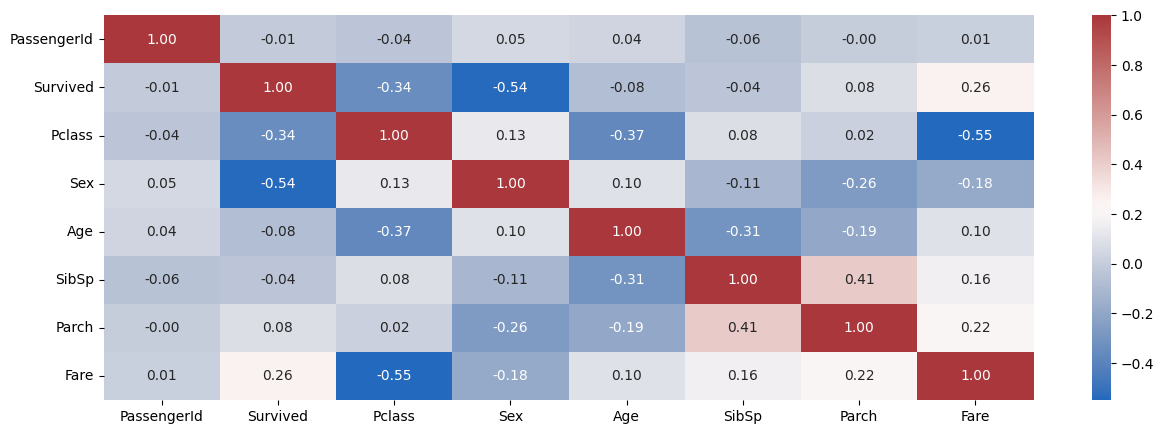

In [62]:
# более читаемая 
sns.heatmap(df.corr(),cmap='vlag',annot=True,fmt='0.2f')

неповторимый идеал

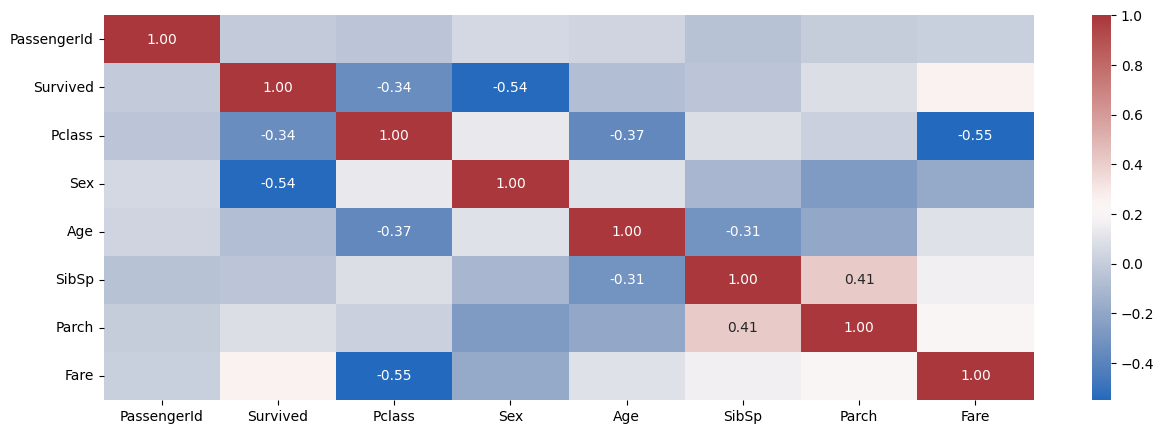

In [64]:
ax = sns.heatmap(df.corr(), cmap="vlag", annot=True, fmt="0.2f")
for t in ax.texts:
    if float(t.get_text()) >= 0.3 or float(t.get_text()) <= -0.3:
        t.set_text(t.get_text())
    else:
        t.set_text("")

распределение количества билетов разных классов при помощи bar plot.

In [65]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/iad34/seminars/master/materials/data_sem1.csv",
    sep=";",
)

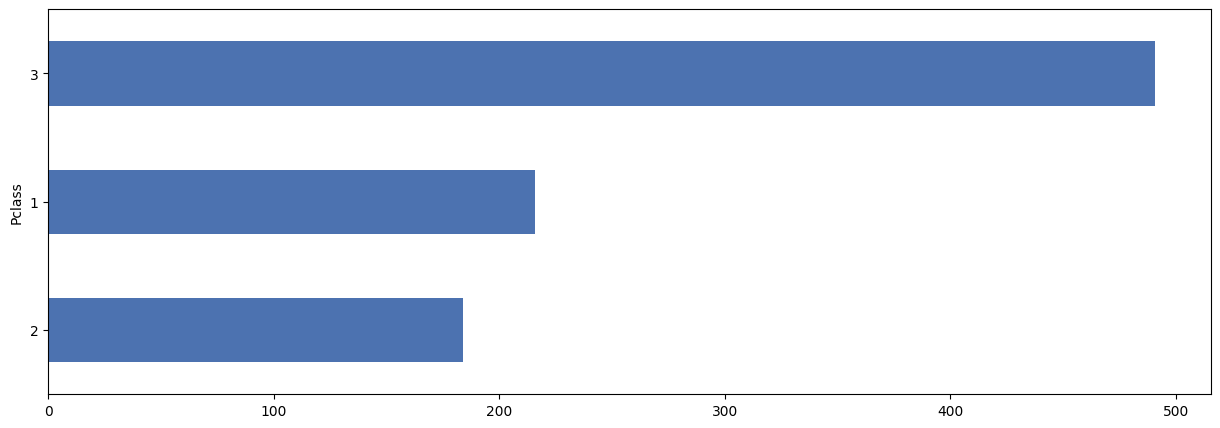

In [68]:
df.groupby("Pclass")["Name"].nunique().sort_values().plot(kind="barh");

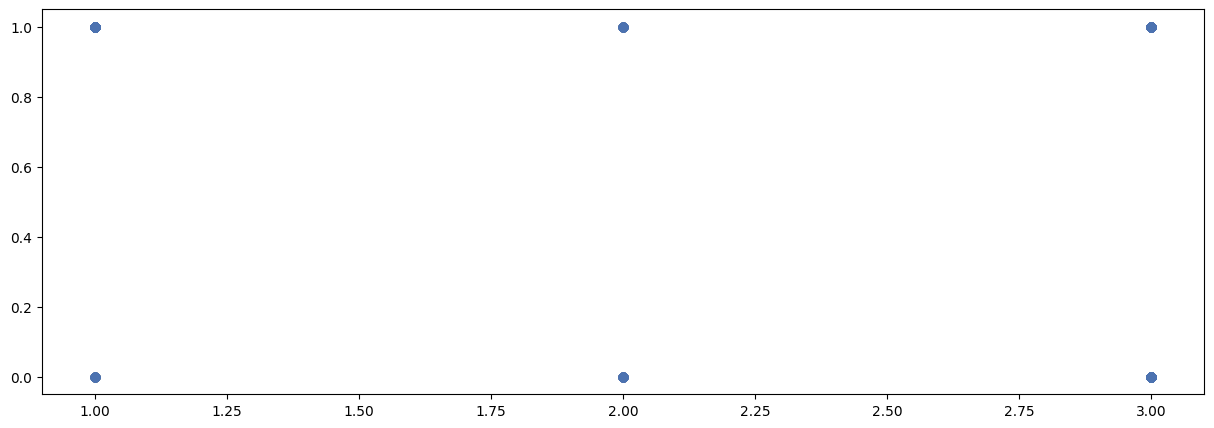

In [69]:
# как не нужно делать scatter
plt.scatter(df['Pclass'],df['Survived'])

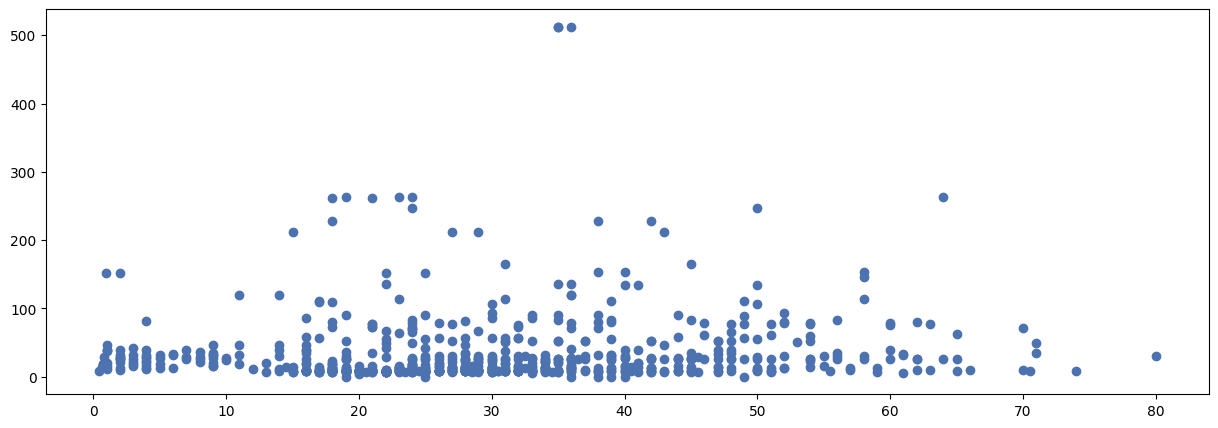

In [70]:
# как нужно делать 
plt.scatter(df["Age"],df["Fare"])

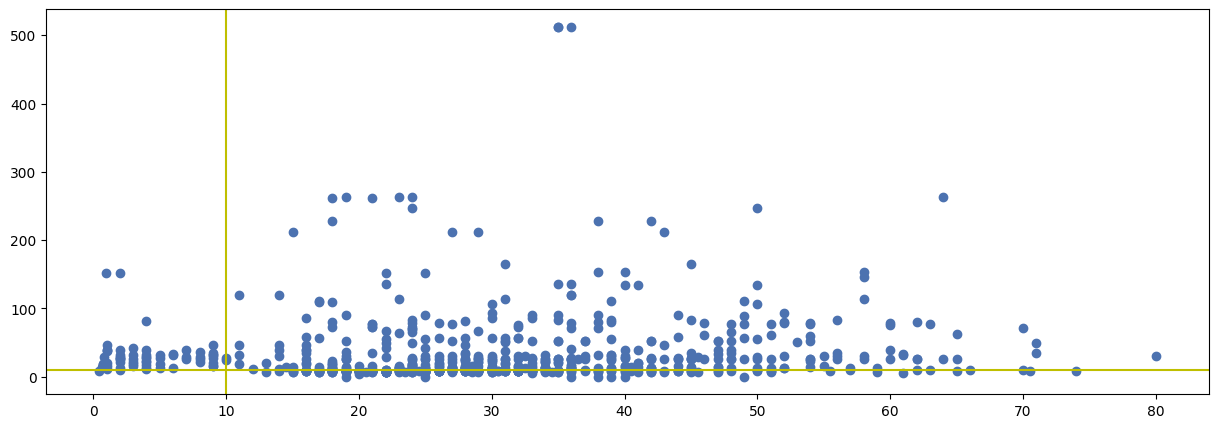

In [71]:
# можно дополнить оси 
plt.scatter(df["Age"],df["Fare"])
plt.axhline(10,c='y')
plt.axvline(10,c='y')

НЕСКОЛЬКО ГРАФИКОВ НА ОДНОЙ ФИГУРЕ

В способе выше мы должны каждый раз переключаться между тем, где мы рисуем, при помощи plt.subplot(n_rows, n_cols, idx). Часто это не очень удобно, поэтому давайте посмотрим на другой способ взаимодействия с подграфиками. Этот способ позволит, например, удобно итерироваться в цикле по графикам и отрисовывать что-то.

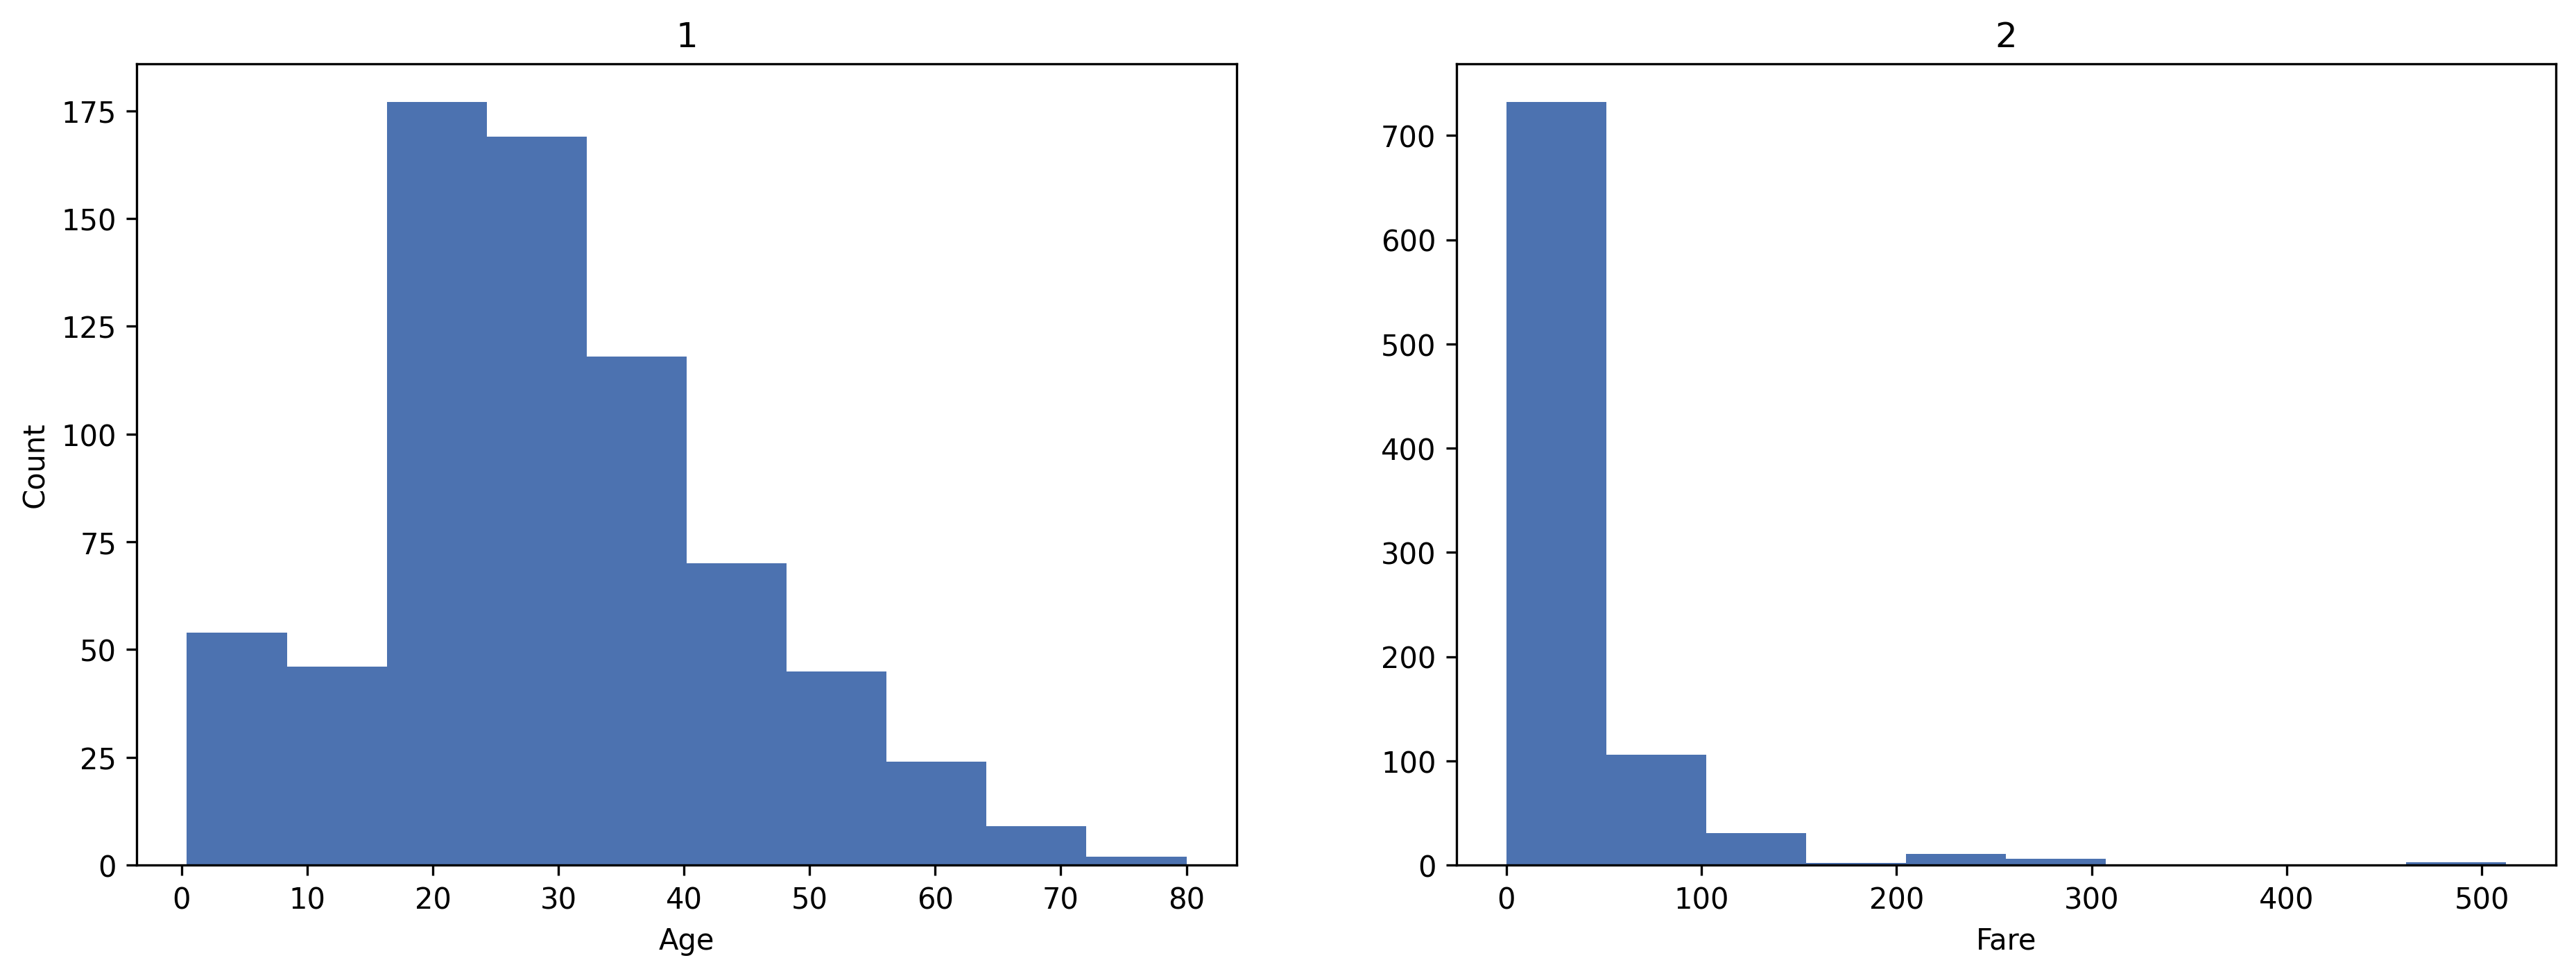

In [72]:
plt.figure(figsize=(15,5),dpi=300)

plt.subplot(1,2,1)
plt.title('1')
plt.hist(df.Age)
plt.ylabel('Count')
plt.xlabel('Age')

plt.subplot(1,2,2)
plt.title('2')
plt.hist(df.Fare)
plt.xlabel("Fare")

plt.show()

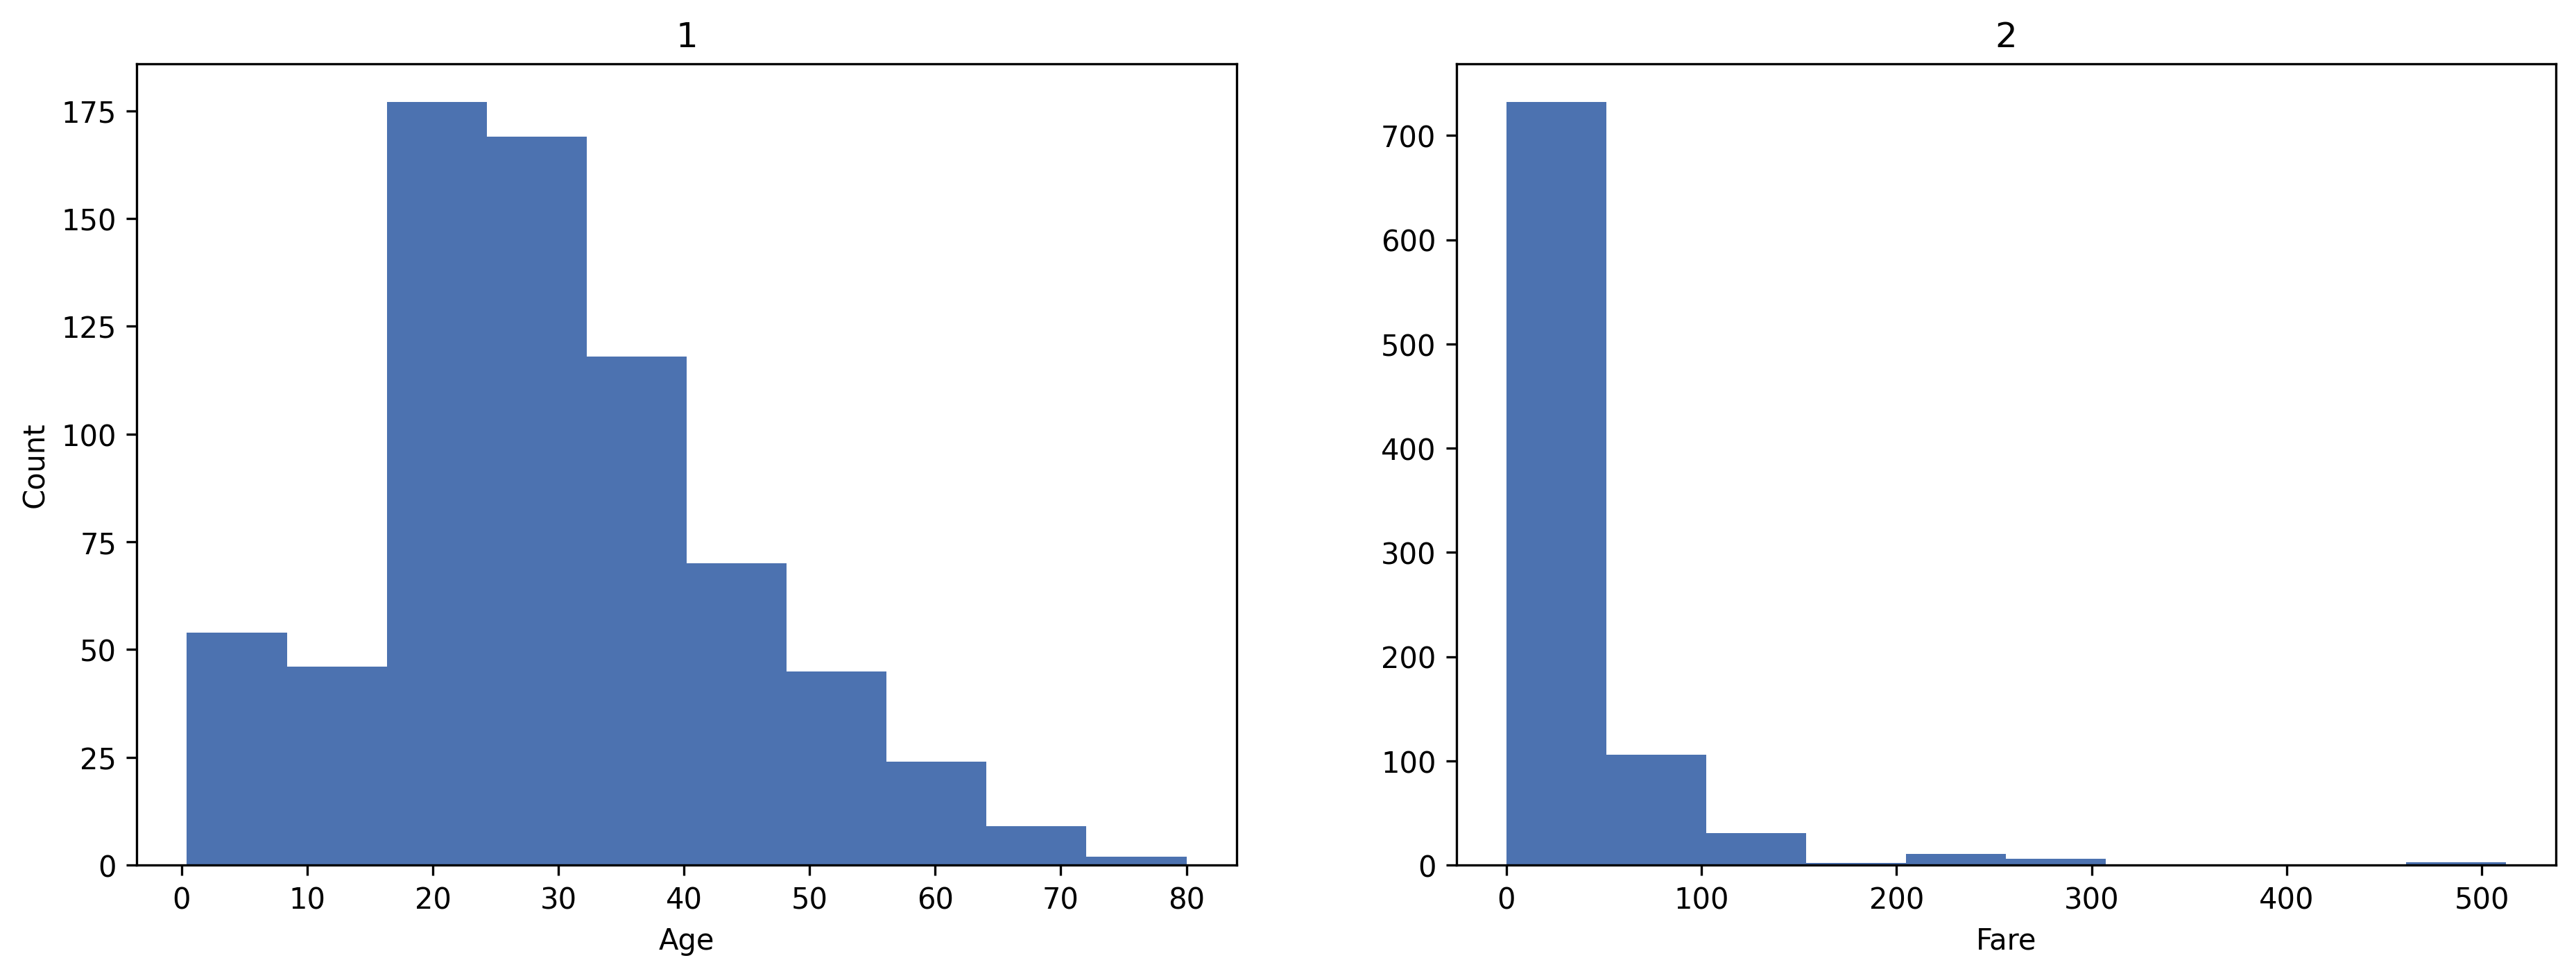

In [73]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5), dpi=300)

axs[0].set_title("1")
axs[0].hist(df["Age"])
axs[0].set_ylabel("Count")
axs[0].set_xlabel("Age")

axs[1].set_title("2")
axs[1].hist(df["Fare"])
axs[1].set_xlabel("Fare")

plt.show()